# BCM vs Hydro/DMO: Full Statistics Comparison

Compare the Baryon Correction Model (arico20) against TNG hydrodynamical and DMO baselines
across all 8 summary statistics: $P(k)$, $C_\ell$, PDF, Peaks, Minima, $V_0$, $V_1$, $V_2$.

For each statistic we compute:
1. Raw suppression ratios $S/S_{\rm DMO}$
2. The BCM response fraction $F_{\rm BCM} = (S_{\rm BCM} - S_{\rm DMO})/(S_{\rm Hydro} - S_{\rm DMO})$
3. Overlay against cumulative Replace model $F$ for comparison

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scienceplots
import NG_stats_analysis as NGstats
plt.style.use(['science', 'notebook'])

In [3]:
# Physical constants
BOX_SIZE = 205  # Mpc/h
GRID_3D = 4096
K_NYQUIST = np.pi * GRID_3D / BOX_SIZE  # ~62.8 h/Mpc

FOV_DEG = 5.0
FOV_RAD = FOV_DEG * np.pi / 180
RT_GRID = 1024
ELL_NYQUIST = np.pi * RT_GRID / FOV_RAD  # ~36864

# Redshift configuration
REDSHIFTS = [0.5, 1.0, 1.5, 2.0]
Z_INDICES = [13, 23, 30, 36]
z_labels = ['$z_s = 0.5$', '$z_s = 1.0$', '$z_s = 1.5$', '$z_s = 2.0$']

KAPPA_REDSHIFTS = {
    1: 0.034, 2: 0.070, 3: 0.105, 4: 0.142, 5: 0.179,
    6: 0.216, 7: 0.255, 8: 0.294, 9: 0.335, 10: 0.376,
    11: 0.418, 12: 0.462, 13: 0.506, 14: 0.552, 15: 0.599,
    16: 0.648, 17: 0.698, 18: 0.749, 19: 0.803, 20: 0.858,
    21: 0.914, 22: 0.973, 23: 1.034, 24: 1.097, 25: 1.163,
    26: 1.231, 27: 1.302, 28: 1.375, 29: 1.452, 30: 1.532,
    31: 1.615, 32: 1.703, 33: 1.794, 34: 1.889, 35: 1.989,
    36: 2.094, 37: 2.203, 38: 2.319, 39: 2.440, 40: 2.568
}
REDSHIFTS_ALL = list(KAPPA_REDSHIFTS.values())

# Statistics to compare
STATISTICS = ['Pk', 'Cl', 'pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

# BCM models with precomputed stats (extend as more become available)
BCM_MODELS = ['arico20']

# Per-statistic masking parameters (matching response_analysis_h5.ipynb exactly)
STAT_CONFIG = {
    'Pk':     {'mask_all_small': False, 'threshold': 0.03, 'k_nyquist': 63},
    'Cl':     {'mask_all_small': False, 'threshold': 0.03, 'k_nyquist': 1e6},
    'pdf':    {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'peaks':  {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'minima': {'mask_all_small': True,  'threshold': 0.01, 'k_nyquist': 5},
    'V0':     {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'V1':     {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'V2':     {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
}

# Per-statistic x-axis configuration
STAT_XAXIS = {
    'Pk':     {'bin_key': 'k_bins',        'xlabel': r'$k\,[h\,{\rm Mpc}^{-1}]$', 'xscale': 'log',    'xlim': (0.1, 63)},
    'Cl':     {'bin_key': 'ell_bins',      'xlabel': r'$\ell$',                     'xscale': 'log',    'xlim': (1e2, 4e4)},
    'pdf':    {'bin_key': 'sn_bin_edges',  'xlabel': r'$\nu$ (S/N)',               'xscale': 'linear', 'xlim': (-4, 8)},
    'peaks':  {'bin_key': 'sn_bin_edges',  'xlabel': r'$\nu$ (S/N)',               'xscale': 'linear', 'xlim': (-4, 8)},
    'minima': {'bin_key': 'sn_bin_edges',  'xlabel': r'$\nu$ (S/N)',               'xscale': 'linear', 'xlim': (-4, 8)},
    'V0':     {'bin_key': 'mf_thresholds', 'xlabel': r'$\nu$',                     'xscale': 'linear', 'xlim': (-4, 8)},
    'V1':     {'bin_key': 'mf_thresholds', 'xlabel': r'$\nu$',                     'xscale': 'linear', 'xlim': (-4, 8)},
    'V2':     {'bin_key': 'mf_thresholds', 'xlabel': r'$\nu$',                     'xscale': 'linear', 'xlim': (-4, 8)},
}

# Statistics where bins are values directly (not edges needing center conversion)
DIRECT_BIN_STATS = ['Cl', 'Pk', 'V0', 'V1', 'V2']

# Stat display labels
STAT_LABELS = {
    'Pk': r'$P(k)$', 'Cl': r'$C_\ell$', 'pdf': 'PDF',
    'peaks': 'Peaks', 'minima': 'Minima',
    'V0': r'$V_0$', 'V1': r'$V_1$', 'V2': r'$V_2$'
}

# Cumulative replace models for overlay comparison
CUM_OVERLAY_MODELS = [
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5',
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_1.0',
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0',
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0',
]

print(f'k_Nyquist = {K_NYQUIST:.1f} h/Mpc')
print(f'ell_Nyquist = {ELL_NYQUIST:.0f}')

k_Nyquist = 62.8 h/Mpc
ell_Nyquist = 36864


In [4]:
base_path = '/mnt/home/mlee1/ceph/hydro_replace_stats'

def load_model_stats(model_name):
    file_path = f'{base_path}/{model_name}/stats.h5'
    try:
        with h5py.File(file_path, 'r') as f:
            data = {key: f[key][()] for key in f.keys()}
            attrs = dict(f.attrs)
        return data, attrs
    except:
        print(f'File not found: {file_path}')
        return None, None

In [5]:
# Load baselines
base_stats = {
    'hydro': load_model_stats('hydro')[0],
    'dmo': load_model_stats('dmo')[0]
}
print('Base stats loaded')

# Load BCM models
bcm_stats = {}
for model in BCM_MODELS:
    data, attrs = load_model_stats(model)
    if data is not None:
        bcm_stats[model] = data
        print(f'  Loaded {model}')
    else:
        print(f'  MISSING: {model}')

# Load cumulative replace models for overlay
replace_stats = {}
for model in CUM_OVERLAY_MODELS:
    data, attrs = load_model_stats(model)
    if data is not None:
        replace_stats[model] = data
print(f'Replace overlay models loaded: {len(replace_stats)}')

Base stats loaded
  Loaded arico20
Replace overlay models loaded: 4


In [6]:
# Validate data shapes across all models
print('Data shape validation:')
print(f'{"Stat":<8} | {"hydro":>20} | {"dmo":>20} | {"arico20":>20}')
print('-' * 75)
for stat in STATISTICS:
    h_shape = base_stats['hydro'][stat].shape if stat in base_stats['hydro'] else 'N/A'
    d_shape = base_stats['dmo'][stat].shape if stat in base_stats['dmo'] else 'N/A'
    b_shape = bcm_stats['arico20'][stat].shape if stat in bcm_stats['arico20'] else 'N/A'
    print(f'{stat:<8} | {str(h_shape):>20} | {str(d_shape):>20} | {str(b_shape):>20}')

Data shape validation:
Stat     |                hydro |                  dmo |              arico20
---------------------------------------------------------------------------
Pk       |       (20, 40, 2896) |       (20, 40, 2896) |       (20, 40, 2896)
Cl       |      (2000, 40, 724) |      (2000, 40, 724) |      (2000, 40, 724)
pdf      |       (2000, 40, 50) |       (2000, 40, 50) |       (2000, 40, 50)
peaks    |       (2000, 40, 50) |       (2000, 40, 50) |       (2000, 40, 50)
minima   |       (2000, 40, 50) |       (2000, 40, 50) |       (2000, 40, 50)
V0       |       (2000, 40, 51) |       (2000, 40, 51) |       (2000, 40, 51)
V1       |       (2000, 40, 51) |       (2000, 40, 51) |       (2000, 40, 51)
V2       |       (2000, 40, 51) |       (2000, 40, 51) |       (2000, 40, 51)


In [7]:
def get_bins(stat_name, ref_data):
    """Get bin centers for a statistic, matching NG_stats_analysis.py logic."""
    xaxis = STAT_XAXIS[stat_name]
    bin_key = xaxis['bin_key']
    if stat_name in DIRECT_BIN_STATS:
        return ref_data[bin_key]
    else:
        bin_edges = ref_data[bin_key]
        return bin_edges[1:] - 0.5 * np.median(np.diff(bin_edges))


def compute_model_F(model_data, hydro_data, dmo_data, stat_name, ref_data):
    """Compute F = (S_model - S_DMO) / (S_Hydro - S_DMO) for any model.
    
    Works for both BCM and Replace models.
    
    Returns dict with bins, F, F_err, means, stderrs, weighted_mean_F, integrated_scores.
    """
    config = STAT_CONFIG[stat_name]
    bins = get_bins(stat_name, ref_data)
    
    # Mean and stderr over realizations (axis=0)
    model_mean = model_data[stat_name].mean(axis=0)    # (N_z, N_bins)
    hydro_mean = hydro_data[stat_name].mean(axis=0)
    dmo_mean = dmo_data[stat_name].mean(axis=0)
    
    n_model = model_data[stat_name].shape[0]
    n_hydro = hydro_data[stat_name].shape[0]
    n_dmo = dmo_data[stat_name].shape[0]
    
    model_stderr = model_data[stat_name].std(axis=0) / np.sqrt(n_model)
    hydro_stderr = hydro_data[stat_name].std(axis=0) / np.sqrt(n_hydro)
    dmo_stderr = dmo_data[stat_name].std(axis=0) / np.sqrt(n_dmo)
    
    # Compute F via NGstats.compute_F
    result = NGstats.compute_F(
        model_mean, hydro_mean, dmo_mean,
        k_bins=bins,
        k_nyquist=config['k_nyquist'],
        mask_all_small=config['mask_all_small'],
        threshold=config['threshold'],
        cum_err=model_stderr,
        hydro_err=hydro_stderr,
        dmo_err=dmo_stderr
    )
    
    if isinstance(result, tuple):
        F, F_err = result
    else:
        F = result
        F_err = np.zeros_like(F)
    
    # Weighted mean F over bins (per z-plane)
    wmean, werr = NGstats.compute_weighted_mean_F(F, F_err, axis=1)
    
    # Integrated scores
    scores = NGstats.compute_integrated_scores(
        model_mean, hydro_mean, dmo_mean,
        R_err=model_stderr, H_err=hydro_stderr, D_err=dmo_stderr,
        axis=1
    )
    
    return {
        'bins': bins,
        'F': F, 'F_err': F_err,
        'model_mean': model_mean, 'hydro_mean': hydro_mean, 'dmo_mean': dmo_mean,
        'model_stderr': model_stderr, 'hydro_stderr': hydro_stderr, 'dmo_stderr': dmo_stderr,
        'weighted_mean_F': wmean, 'weighted_mean_F_err': werr,
        'integrated_scores': scores,
    }

In [8]:
# Compute BCM F for all statistics
bcm_results = {}  # {model_name: {stat_name: results_dict}}

for model_name, model_data in bcm_stats.items():
    bcm_results[model_name] = {}
    print(f'--- {model_name} ---')
    for stat_name in STATISTICS:
        if stat_name in model_data:
            bcm_results[model_name][stat_name] = compute_model_F(
                model_data, base_stats['hydro'], base_stats['dmo'],
                stat_name, base_stats['hydro']
            )
            wm = bcm_results[model_name][stat_name]['weighted_mean_F']
            print(f'  {stat_name}: <F>(z=1) = {wm[23]:.3f}')
        else:
            print(f'  {stat_name}: NOT AVAILABLE')

--- arico20 ---
  Pk: <F>(z=1) = 0.062
  Cl: <F>(z=1) = 1.076
  pdf: <F>(z=1) = 0.744
  peaks: <F>(z=1) = 0.854
  minima: <F>(z=1) = 0.515
  V0: <F>(z=1) = 0.930
  V1: <F>(z=1) = 0.953
  V2: <F>(z=1) = 1.013


/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: invalid value encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: invalid value encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: divide by zero encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: divide by zero encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)


In [9]:
# Summary table of weighted-mean F
print('=' * 70)
print('BCM RESPONSE FRACTION SUMMARY: <F> (inverse-variance weighted mean)')
print('=' * 70)

for model_name in bcm_results:
    print(f'\n--- {model_name} ---')
    print(f'{"Statistic":<10} | {"z=0.5":>8} | {"z=1.0":>8} | {"z=1.5":>8} | {"z=2.0":>8}')
    print('-' * 55)
    for stat_name in STATISTICS:
        if stat_name in bcm_results[model_name]:
            r = bcm_results[model_name][stat_name]
            vals = [r['weighted_mean_F'][z_idx] for z_idx in Z_INDICES]
            print(f'{stat_name:<10} | {vals[0]:>8.3f} | {vals[1]:>8.3f} | {vals[2]:>8.3f} | {vals[3]:>8.3f}')
    
    # Also print IER and chi2_frac
    print(f'\n{"":<10} | {"IER":>8} | {"chi2_frac":>8}')
    print('-' * 35)
    for stat_name in STATISTICS:
        if stat_name in bcm_results[model_name]:
            s = bcm_results[model_name][stat_name]['integrated_scores']
            ier = s['IER'][23] if 'IER' in s else np.nan
            chi2 = s['chi2_frac'][23] if 'chi2_frac' in s else np.nan
            print(f'{stat_name:<10} | {ier:>8.3f} | {chi2:>8.3f}')

BCM RESPONSE FRACTION SUMMARY: <F> (inverse-variance weighted mean)

--- arico20 ---
Statistic  |    z=0.5 |    z=1.0 |    z=1.5 |    z=2.0
-------------------------------------------------------
Pk         |    0.630 |    0.062 |    0.035 |    0.026
Cl         |    0.939 |    1.076 |    1.161 |    1.232
pdf        |    0.632 |    0.744 |    0.832 |    0.942
peaks      |    0.747 |    0.854 |    0.907 |    0.972
minima     |    0.334 |    0.515 |    0.576 |    0.549
V0         |    0.801 |    0.930 |    1.029 |    1.136
V1         |    0.827 |    0.953 |    1.049 |    1.158
V2         |    0.857 |    1.013 |    1.121 |    1.234

           |      IER | chi2_frac
-----------------------------------
Pk         |    0.852 |    0.823
Cl         |    0.707 |    0.827
pdf        |    1.786 |    0.782
peaks      |    0.296 |    0.811
minima     |    0.082 |    0.698
V0         |    3.386 |    0.877
V1         |    0.850 |    0.820
V2         |    4.003 |    0.040


# Raw Comparison: $S/S_{\rm DMO}$

Compare the suppression pattern of the BCM against the TNG hydro target.

In [10]:
def plot_raw_comparison(bcm_result, stat_name, model_name='arico20'):
    """2-row x 4-column figure: top = S/S_DMO, bottom = S_BCM/S_Hydro."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex='col')
    xaxis = STAT_XAXIS[stat_name]
    bins = bcm_result['bins']
    
    for col, (z_idx, z_val, z_lab) in enumerate(zip(Z_INDICES, REDSHIFTS, z_labels)):
        # Top: S/S_DMO
        ax = axes[0, col]
        dmo = bcm_result['dmo_mean'][z_idx]
        with np.errstate(divide='ignore', invalid='ignore'):
            hydro_ratio = bcm_result['hydro_mean'][z_idx] / dmo
            bcm_ratio = bcm_result['model_mean'][z_idx] / dmo
        
        ax.plot(bins, hydro_ratio, 'k-', lw=1.5, label='TNG Hydro')
        ax.plot(bins, bcm_ratio, 'C0-', lw=1.5, label=model_name)
        ax.axhline(1, color='gray', ls='--', lw=0.8)
        ax.set_xscale(xaxis['xscale'])
        ax.set_xlim(xaxis['xlim'])
        ax.set_title(z_lab)
        if col == 0:
            ax.set_ylabel(r'$S / S_{\rm DMO}$')
            ax.legend(fontsize=8)
        
        # Bottom: S_BCM / S_Hydro
        ax = axes[1, col]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = bcm_result['model_mean'][z_idx] / bcm_result['hydro_mean'][z_idx]
        ax.plot(bins, ratio, 'C0-', lw=1.5)
        ax.axhline(1, color='gray', ls='--', lw=0.8)
        ax.fill_between(xaxis['xlim'], 0.99, 1.01, alpha=0.15, color='green',
                        transform=ax.get_yaxis_transform())
        ax.set_xscale(xaxis['xscale'])
        ax.set_xlim(xaxis['xlim'])
        ax.set_xlabel(xaxis['xlabel'])
        if col == 0:
            ax.set_ylabel(r'$S_{\rm BCM} / S_{\rm Hydro}$')
    
    fig.suptitle(f'{STAT_LABELS[stat_name]}: {model_name} vs TNG Hydro', fontsize=13)
    plt.tight_layout()
    plt.show()
    return fig

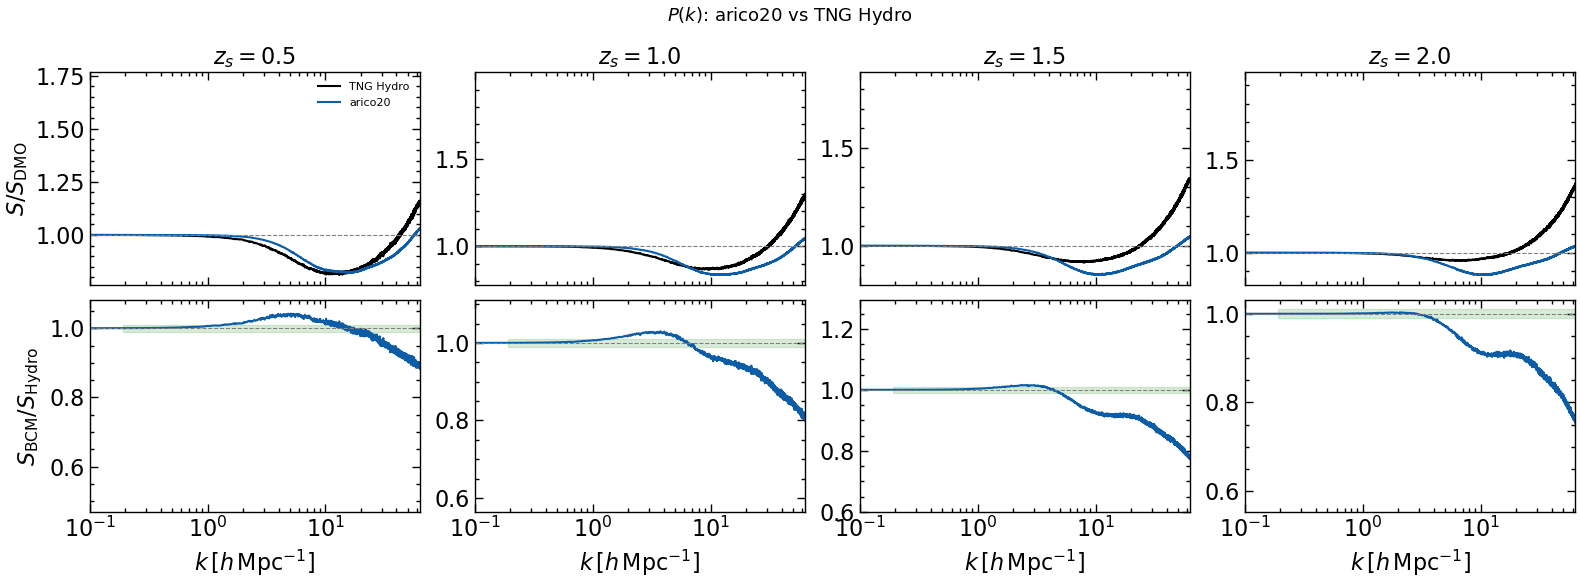

/mnt/sw/nix/store/xxckmjvzwivd4rnrqcqa95zx3fasn2ak-python-3.11.11-view/lib/python3.11/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


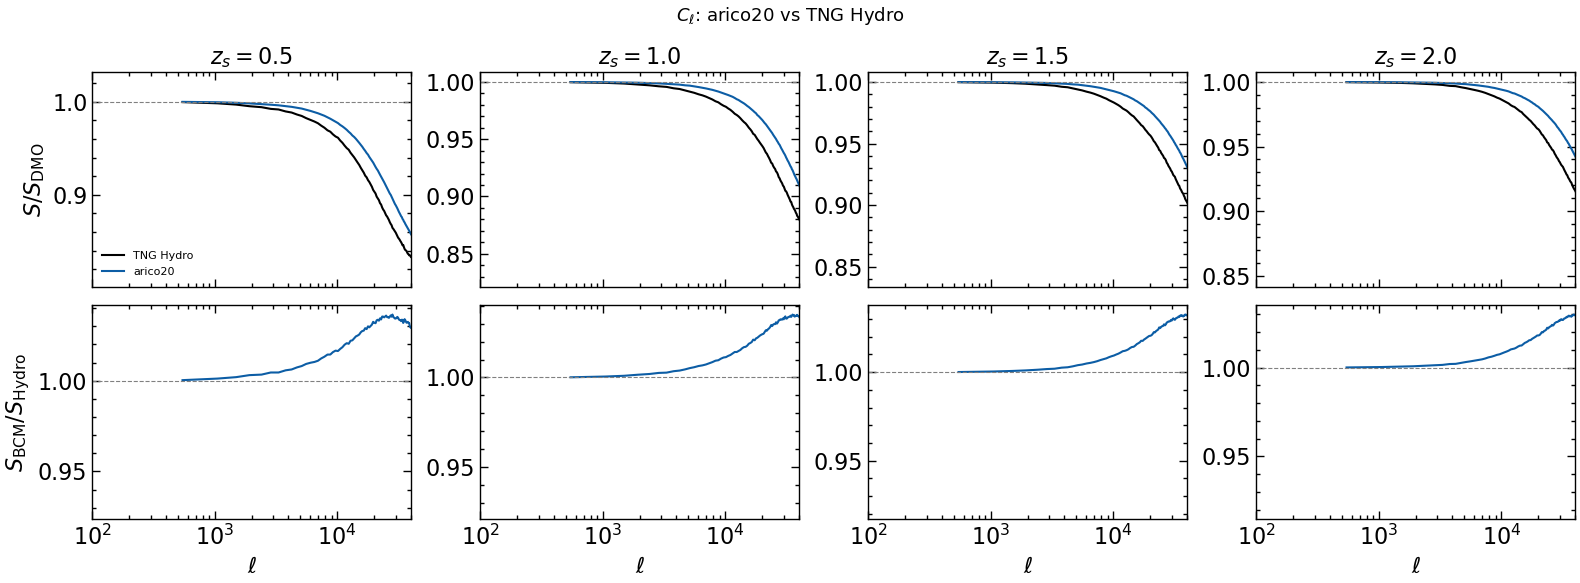

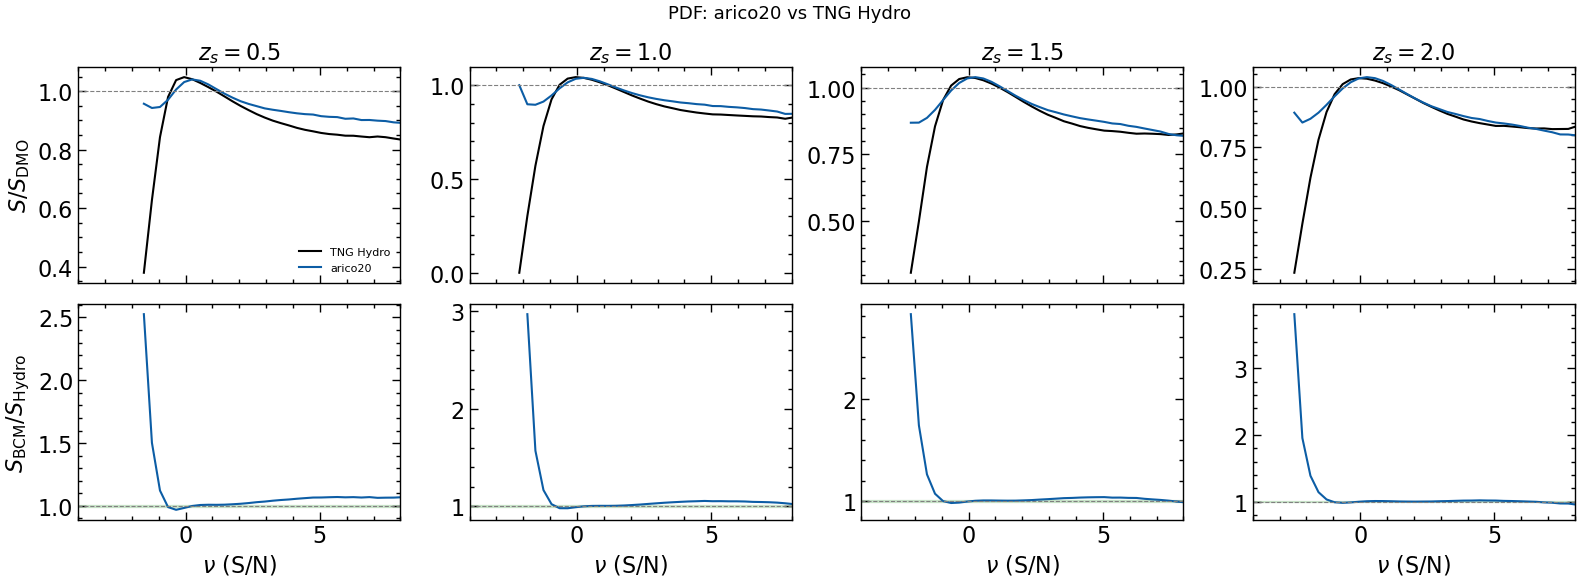

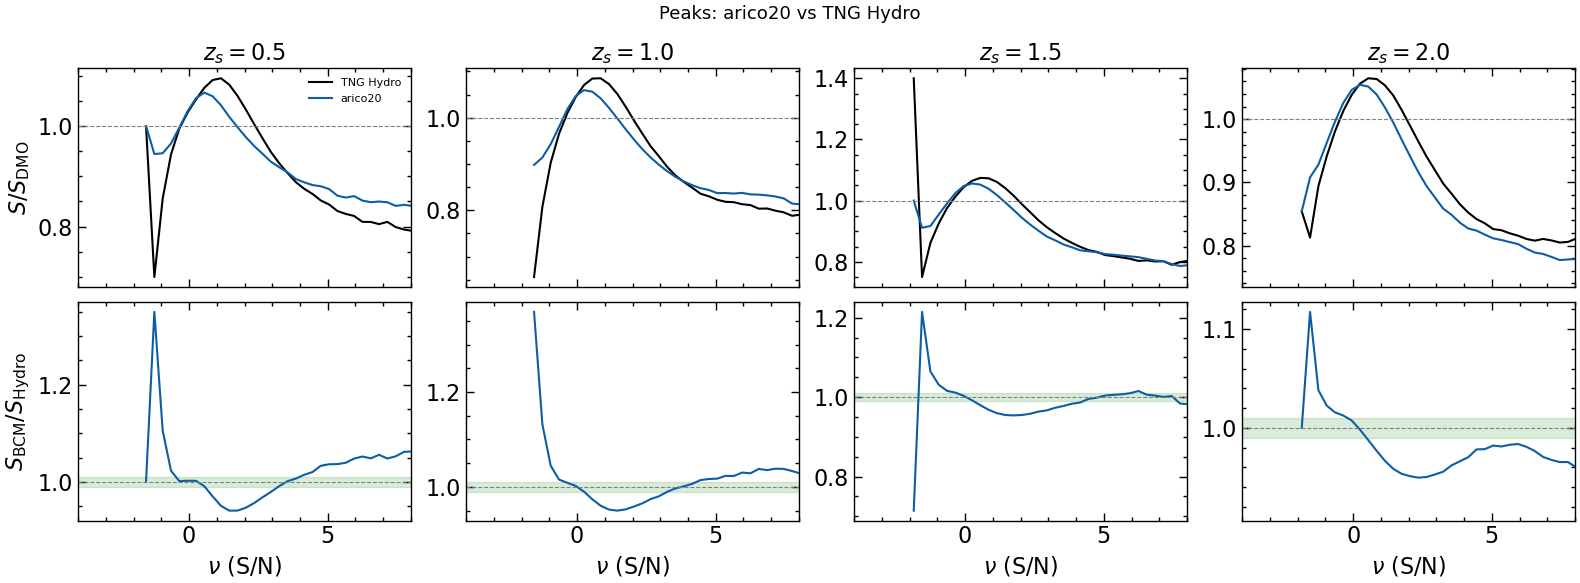

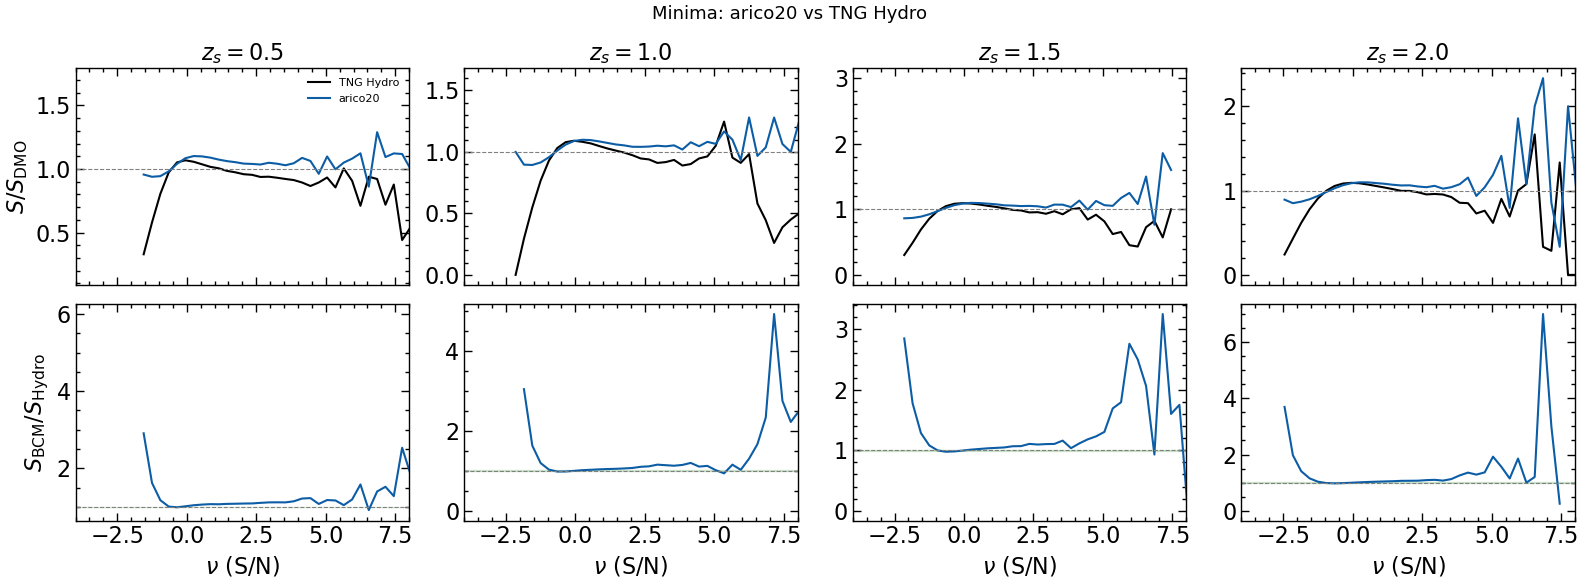

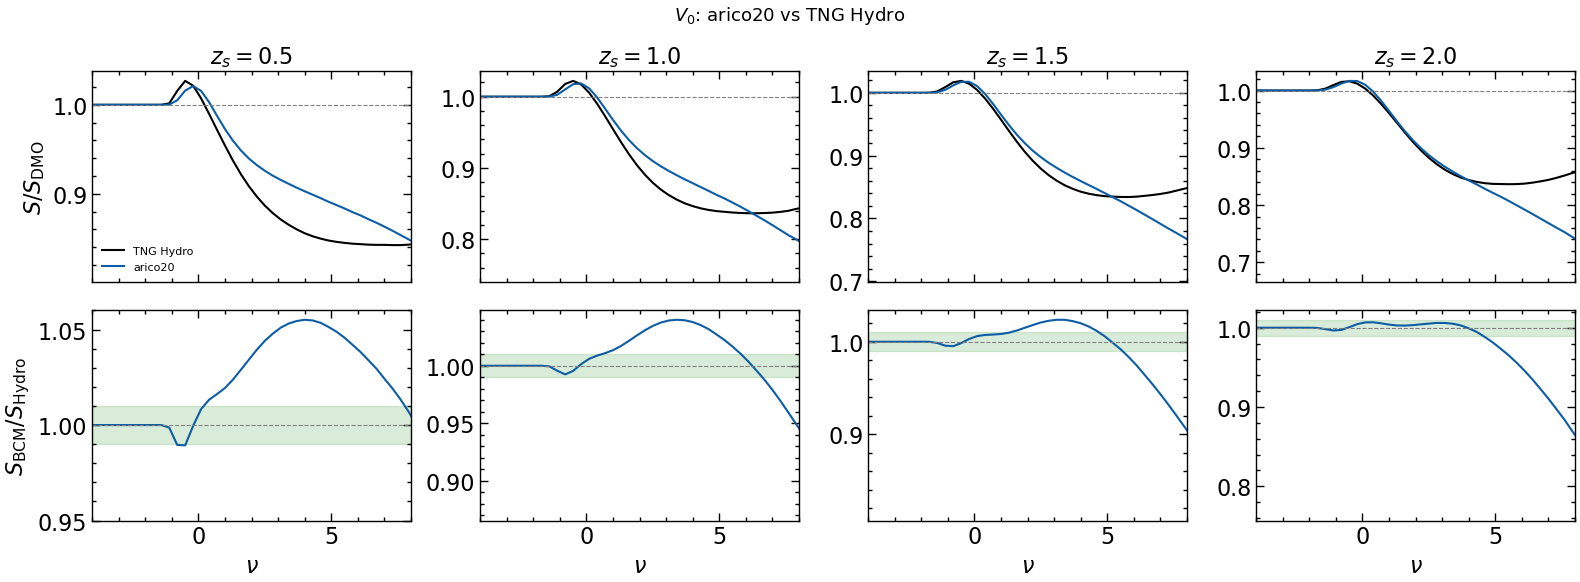

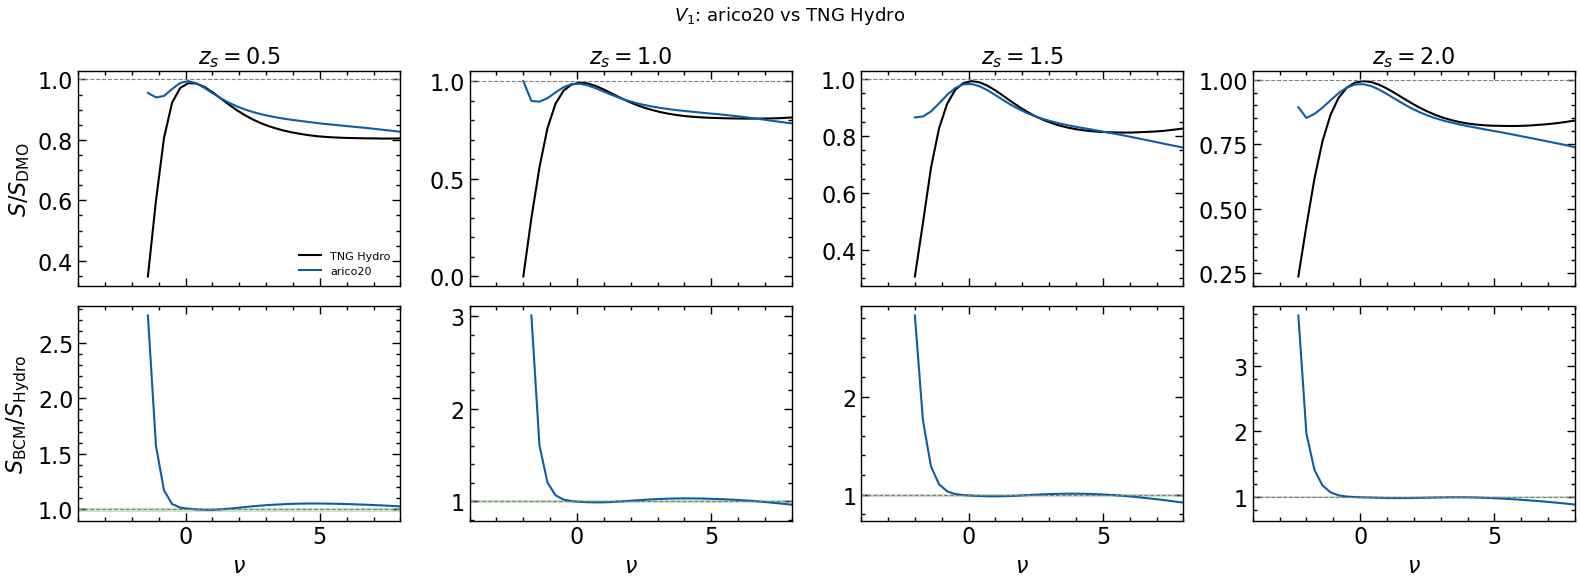

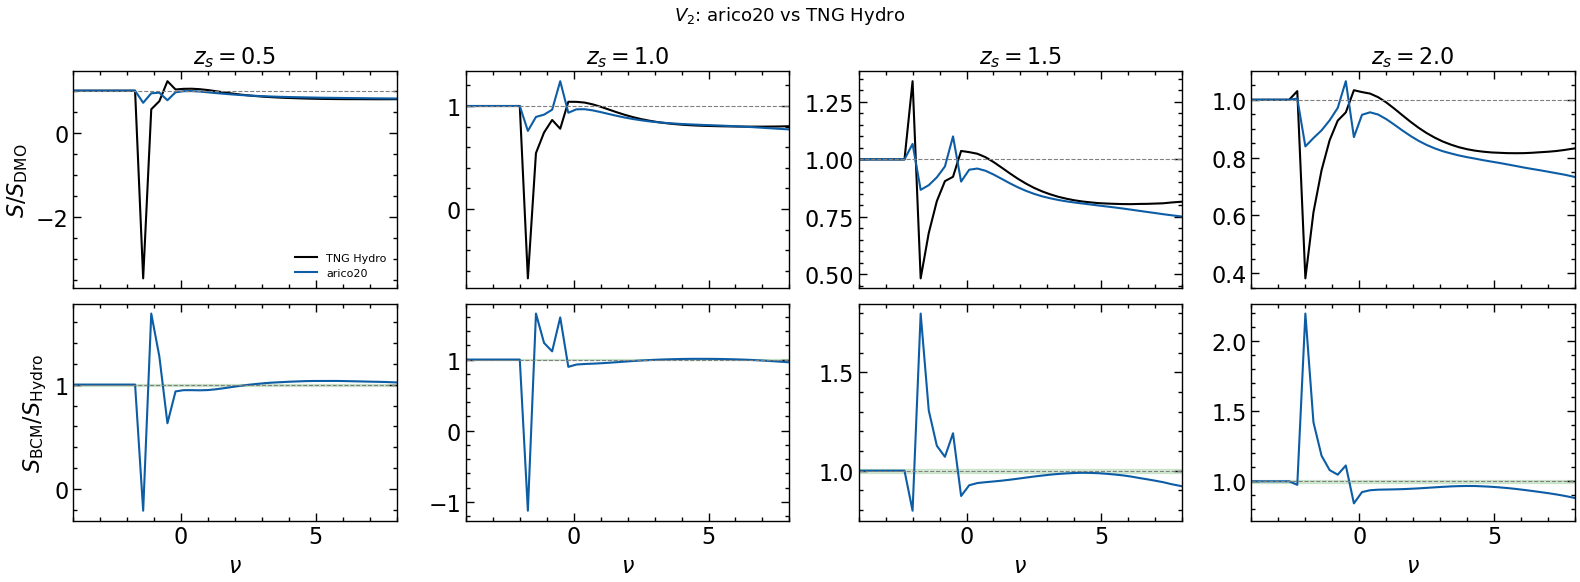

In [11]:
for stat_name in STATISTICS:
    for model_name in bcm_results:
        if stat_name in bcm_results[model_name]:
            plot_raw_comparison(bcm_results[model_name][stat_name], stat_name, model_name)

# BCM Response Fraction $F$

$$F_{\rm BCM}(x) = \frac{S_{\rm BCM}(x) - S_{\rm DMO}(x)}{S_{\rm Hydro}(x) - S_{\rm DMO}(x)}$$

- $F = 1$: BCM perfectly reproduces the hydro baryonic effect
- $F = 0$: BCM has no baryonic effect (matches DMO)
- $F > 1$: BCM over-predicts the baryonic effect

In [12]:
def plot_bcm_F(bcm_result, stat_name, model_name='arico20'):
    """Plot F_BCM(bins) at 4 redshifts with error bands."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    xaxis = STAT_XAXIS[stat_name]
    bins = bcm_result['bins']
    
    for col, (z_idx, z_val, z_lab) in enumerate(zip(Z_INDICES, REDSHIFTS, z_labels)):
        ax = axes[col]
        F = bcm_result['F'][z_idx]
        F_err = bcm_result['F_err'][z_idx]
        F_mean = bcm_result['weighted_mean_F'][z_idx]
        
        valid = np.isfinite(F)
        ax.plot(bins[valid], F[valid], 'C0-', lw=1.5)
        ax.fill_between(bins[valid], (F - F_err)[valid], (F + F_err)[valid],
                        alpha=0.3, color='C0')
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.axhline(1, color='k', ls='--', lw=0.8)
        ax.set_xscale(xaxis['xscale'])
        ax.set_xlim(xaxis['xlim'])
        ax.set_ylim(-0.5, 1.5)
        F_str = f'{F_mean:.3f}' if np.isfinite(F_mean) else 'N/A'
        ax.set_title(f'{z_lab}\n' + r'$\langle F \rangle$' + f' = {F_str}')
        ax.set_xlabel(xaxis['xlabel'])
        if col == 0:
            ax.set_ylabel(r'$F_{\rm BCM}$')
        ax.grid(alpha=0.3)
    
    fig.suptitle(f'{STAT_LABELS[stat_name]}: BCM Response Fraction ({model_name})', fontsize=13)
    plt.tight_layout()
    plt.show()
    return fig

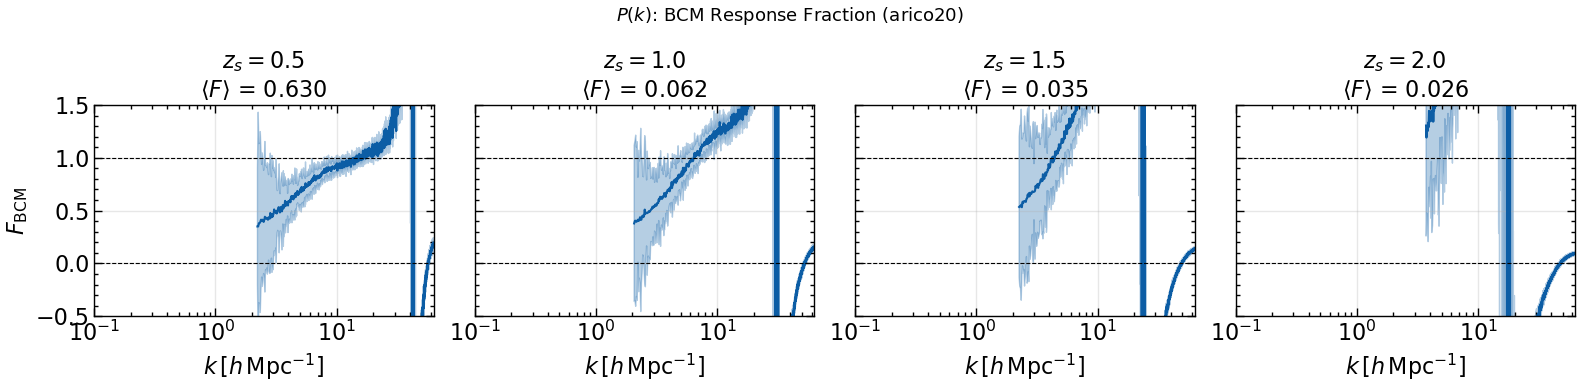

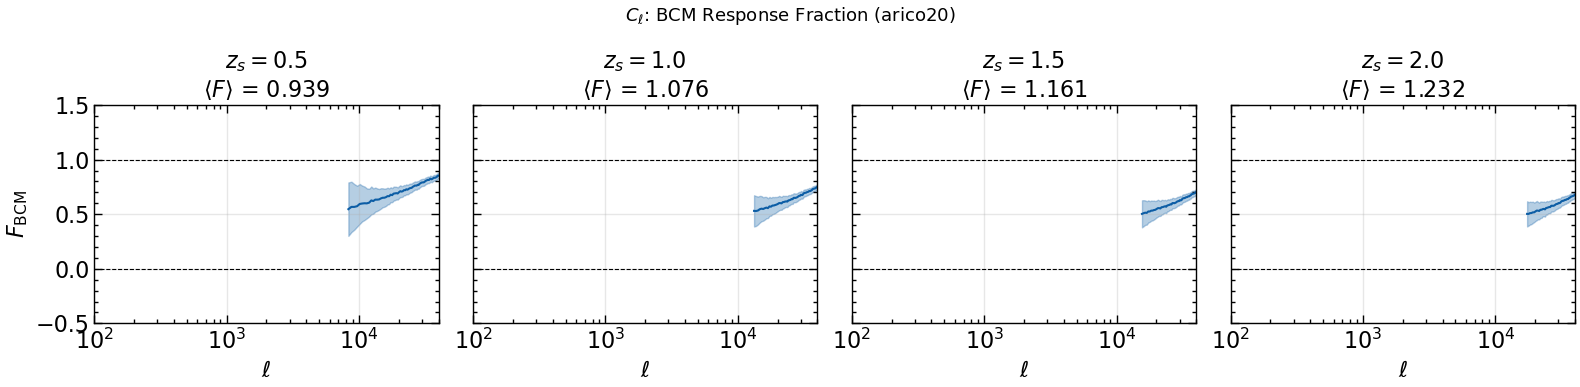

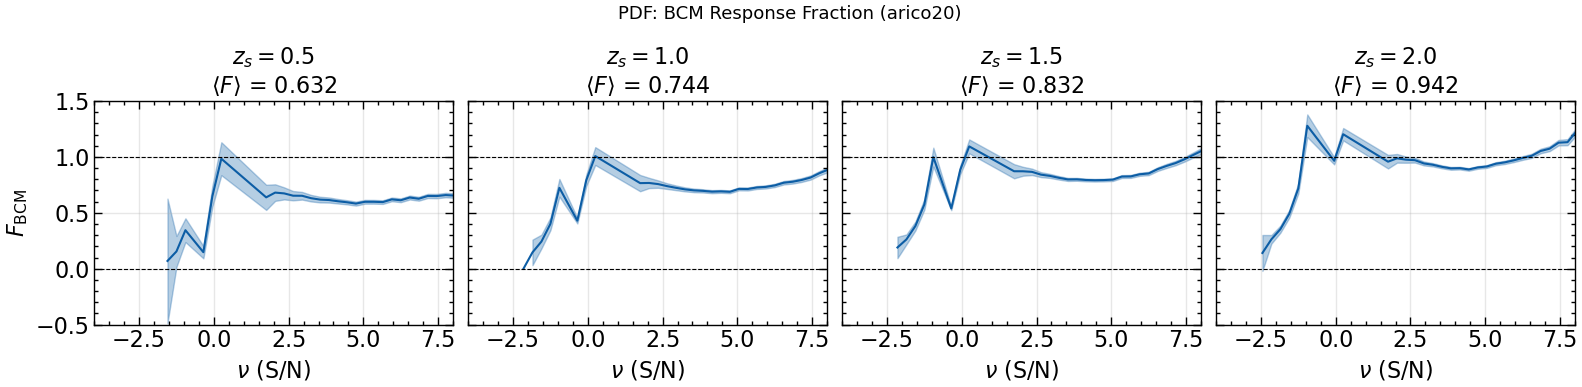

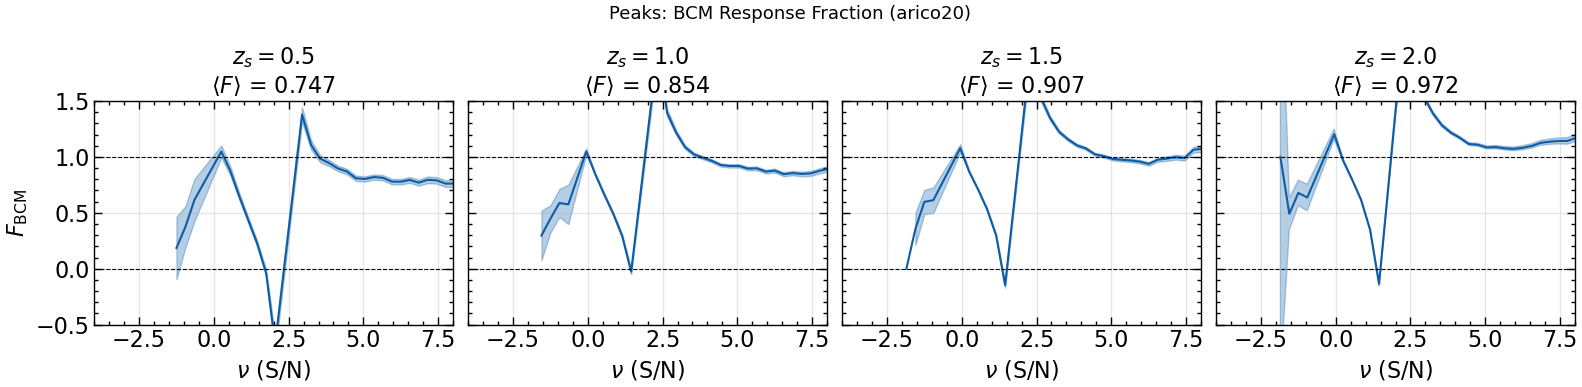

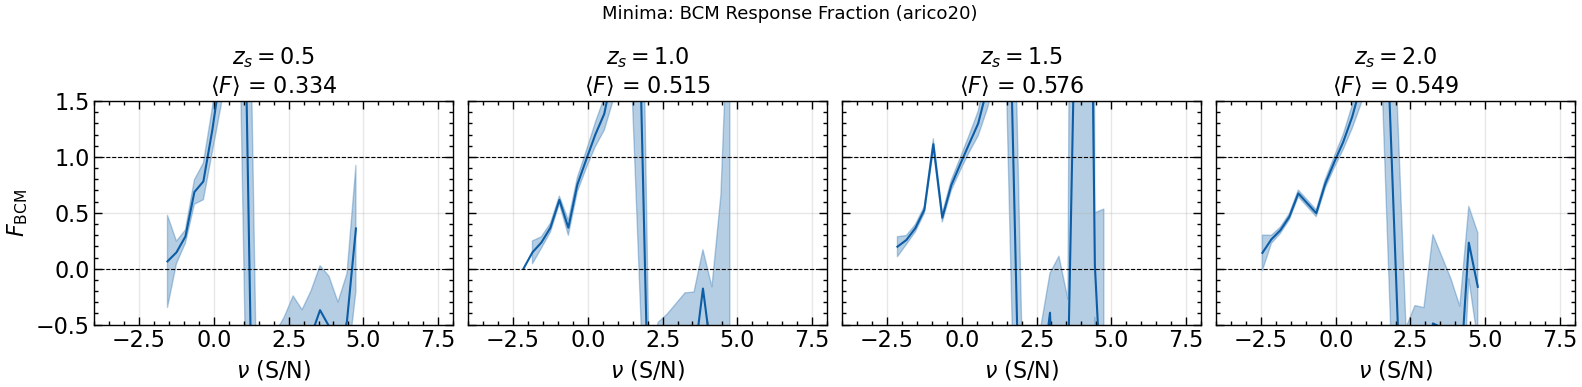

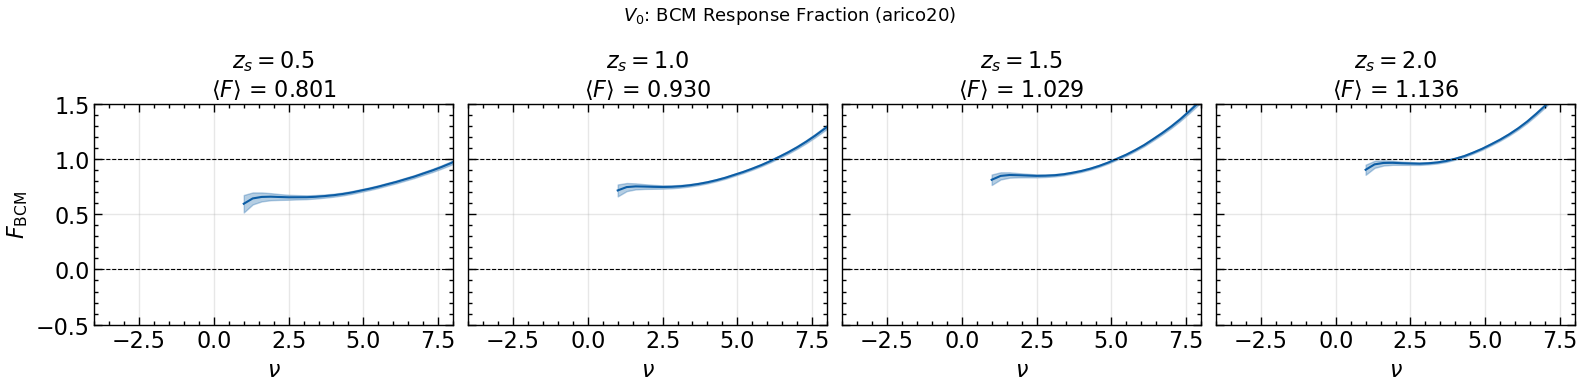

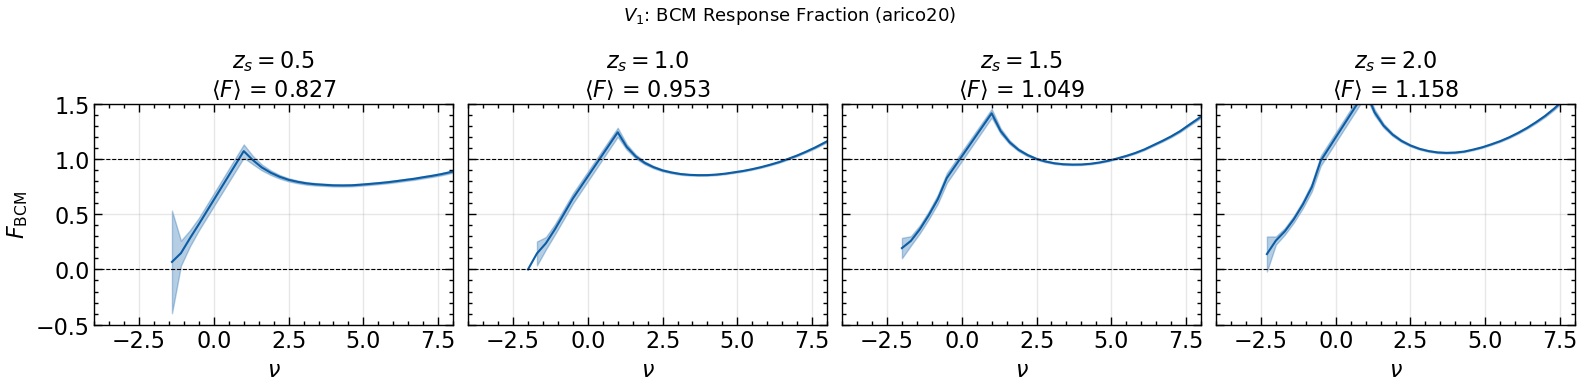

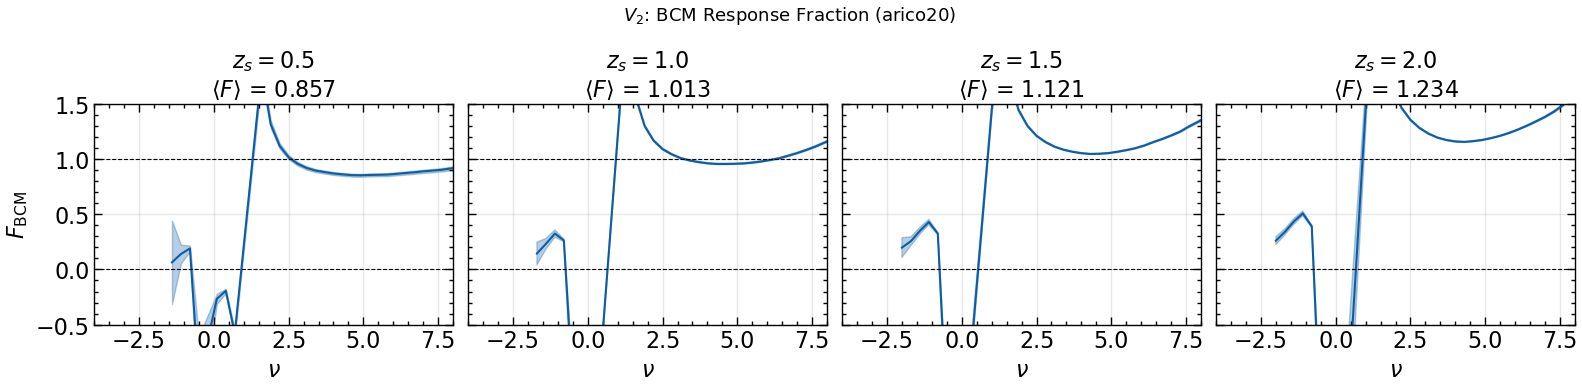

In [13]:
for stat_name in STATISTICS:
    for model_name in bcm_results:
        if stat_name in bcm_results[model_name]:
            plot_bcm_F(bcm_results[model_name][stat_name], stat_name, model_name)

In [14]:
# Compute F for the cumulative replace overlay models
replace_F_results = {}  # {stat_name: {model_name: results_dict}}

for stat_name in STATISTICS:
    replace_F_results[stat_name] = {}
    for model_name, model_data in replace_stats.items():
        if stat_name in model_data:
            replace_F_results[stat_name][model_name] = compute_model_F(
                model_data, base_stats['hydro'], base_stats['dmo'],
                stat_name, base_stats['hydro']
            )
print('Replace model F computed for all statistics')

Replace model F computed for all statistics


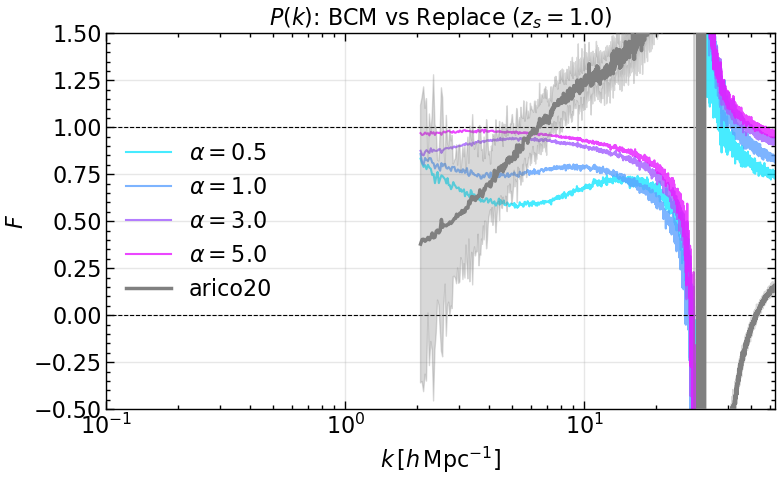

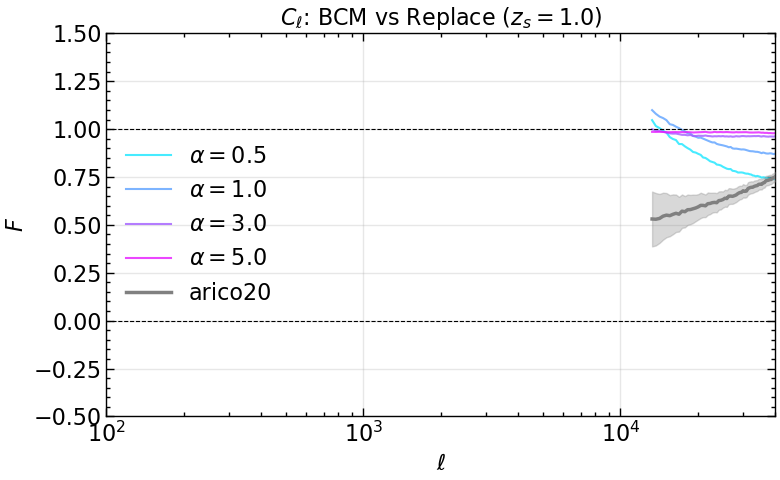

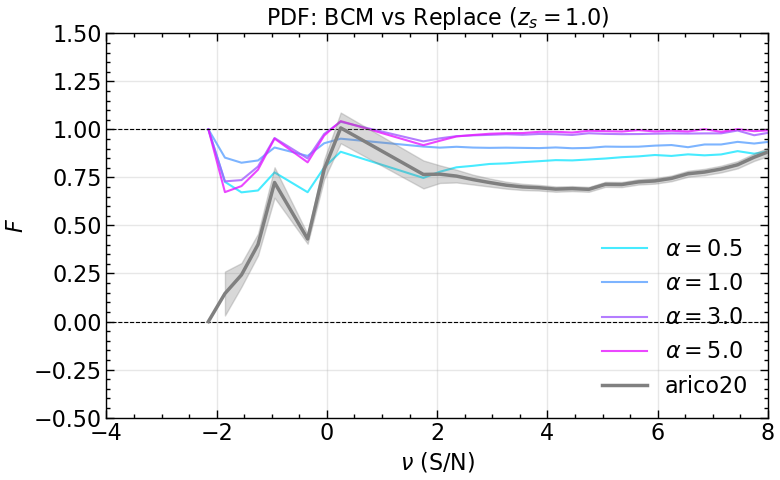

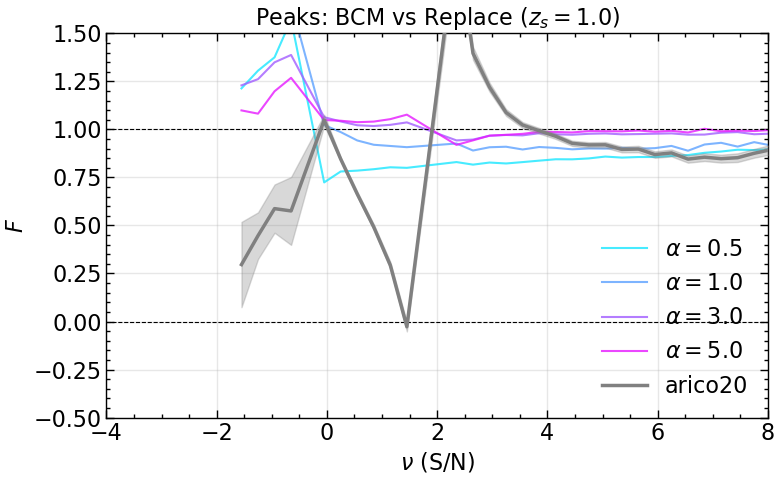

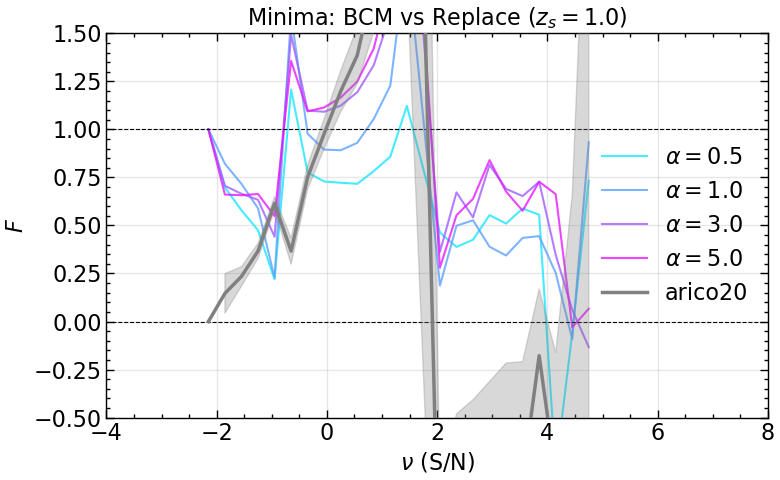

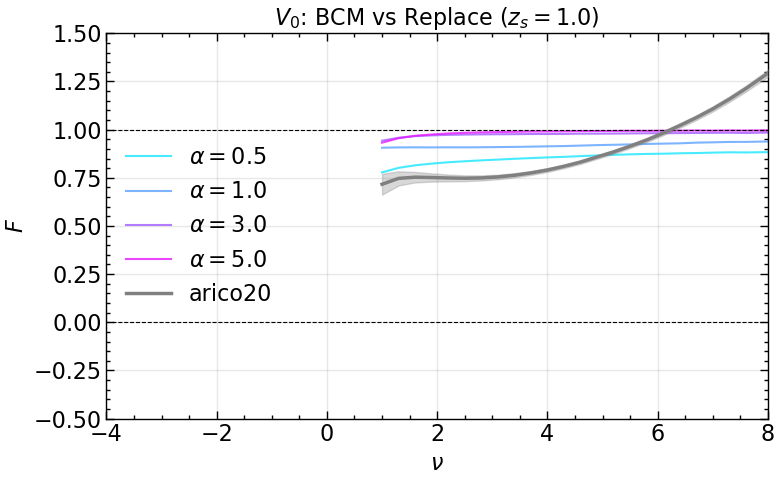

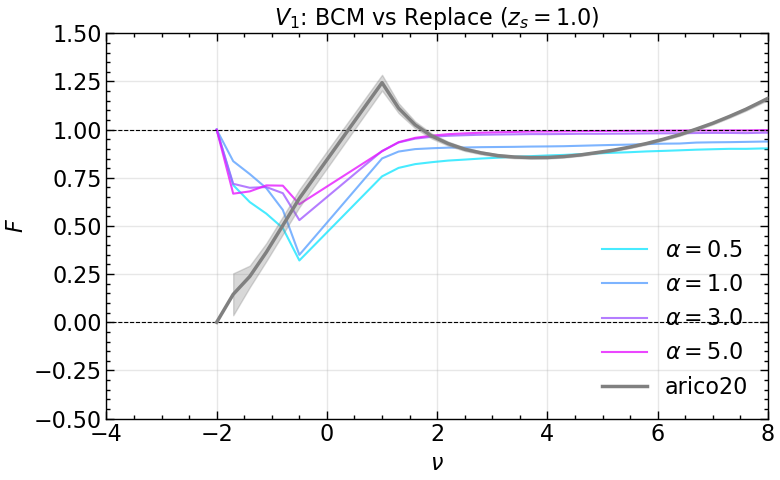

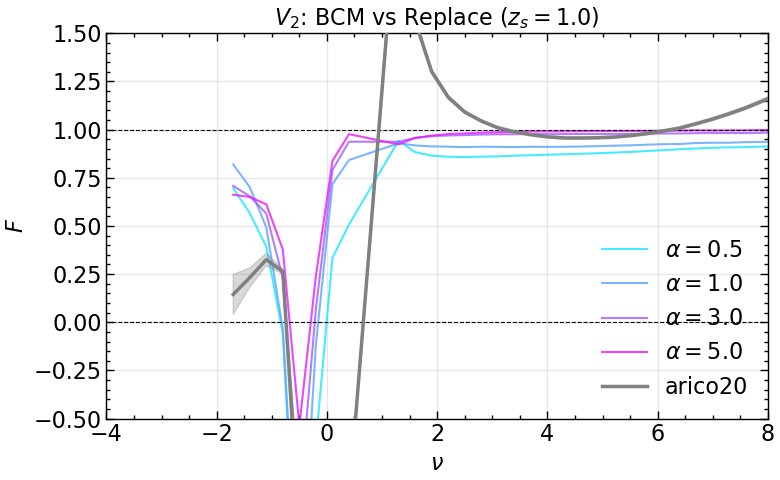

In [15]:
def plot_bcm_vs_replace_F(bcm_result, replace_results_stat, stat_name, 
                          model_name='arico20', z_idx=23, z_val=1.0):
    """Overlay BCM F against cumulative Replace model F at a single redshift."""
    fig, ax = plt.subplots(figsize=(8, 5))
    xaxis = STAT_XAXIS[stat_name]
    bins = bcm_result['bins']
    
    # Plot replace models
    alpha_map = {'Ro_0.5': r'$\alpha=0.5$', 'Ro_1.0': r'$\alpha=1.0$',
                 'Ro_3.0': r'$\alpha=3.0$', 'Ro_5.0': r'$\alpha=5.0$'}
    colors = plt.cm.cool(np.linspace(0.1, 0.9, len(replace_results_stat)))
    
    for i, (rep_model, rep_data) in enumerate(replace_results_stat.items()):
        F_rep = rep_data['F'][z_idx]
        valid = np.isfinite(F_rep)
        # Extract alpha label from model name
        alpha_key = [k for k in alpha_map if k in rep_model]
        label = alpha_map[alpha_key[0]] if alpha_key else rep_model.split('_')[-1]
        ax.plot(bins[valid], F_rep[valid], '-', color=colors[i], lw=1.5, label=label, alpha=0.8)
    
    # Plot BCM F
    F_bcm = bcm_result['F'][z_idx]
    F_bcm_err = bcm_result['F_err'][z_idx]
    valid = np.isfinite(F_bcm)
    ax.plot(bins[valid], F_bcm[valid], '-', color='gray', lw=2.5, label=model_name, zorder=10)
    ax.fill_between(bins[valid], (F_bcm - F_bcm_err)[valid], (F_bcm + F_bcm_err)[valid],
                    alpha=0.3, color='gray', zorder=9)
    
    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_xscale(xaxis['xscale'])
    ax.set_xlim(xaxis['xlim'])
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel(xaxis['xlabel'])
    ax.set_ylabel(r'$F$')
    ax.set_title(f'{STAT_LABELS[stat_name]}: BCM vs Replace ($z_s = {z_val}$)')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    return fig


# Generate overlay plots for all statistics
for stat_name in STATISTICS:
    for model_name in bcm_results:
        if stat_name in bcm_results[model_name] and stat_name in replace_F_results:
            plot_bcm_vs_replace_F(
                bcm_results[model_name][stat_name],
                replace_F_results[stat_name],
                stat_name, model_name,
                z_idx=23, z_val=1.0
            )

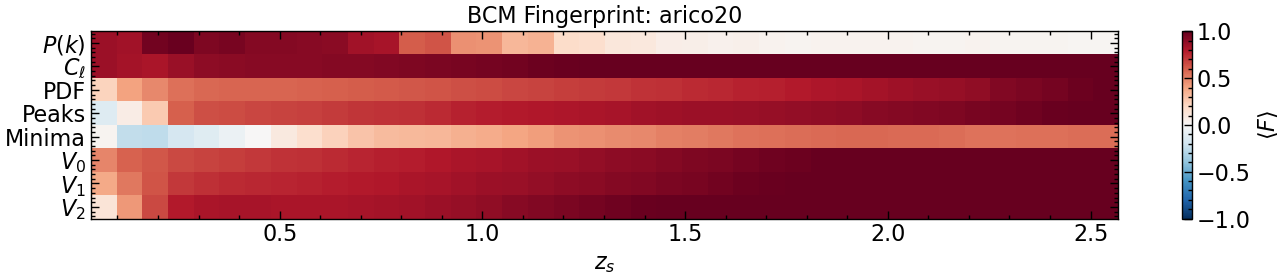

In [16]:
# BCM Fingerprint Heatmap: weighted-mean F across all statistics and redshifts
for model_name in bcm_results:
    n_stats = len(STATISTICS)
    n_z = 40
    
    F_grid = np.full((n_stats, n_z), np.nan)
    for i, stat_name in enumerate(STATISTICS):
        if stat_name in bcm_results[model_name]:
            F_grid[i, :] = bcm_results[model_name][stat_name]['weighted_mean_F']
    
    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(F_grid, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1,
                   extent=[REDSHIFTS_ALL[0], REDSHIFTS_ALL[-1], n_stats - 0.5, -0.5])
    ax.set_yticks(range(n_stats))
    ax.set_yticklabels([STAT_LABELS[s] for s in STATISTICS])
    ax.set_xlabel(r'$z_s$')
    ax.set_title(f'BCM Fingerprint: {model_name}')
    plt.colorbar(im, ax=ax, label=r'$\langle F \rangle$')
    plt.tight_layout()
    plt.show()

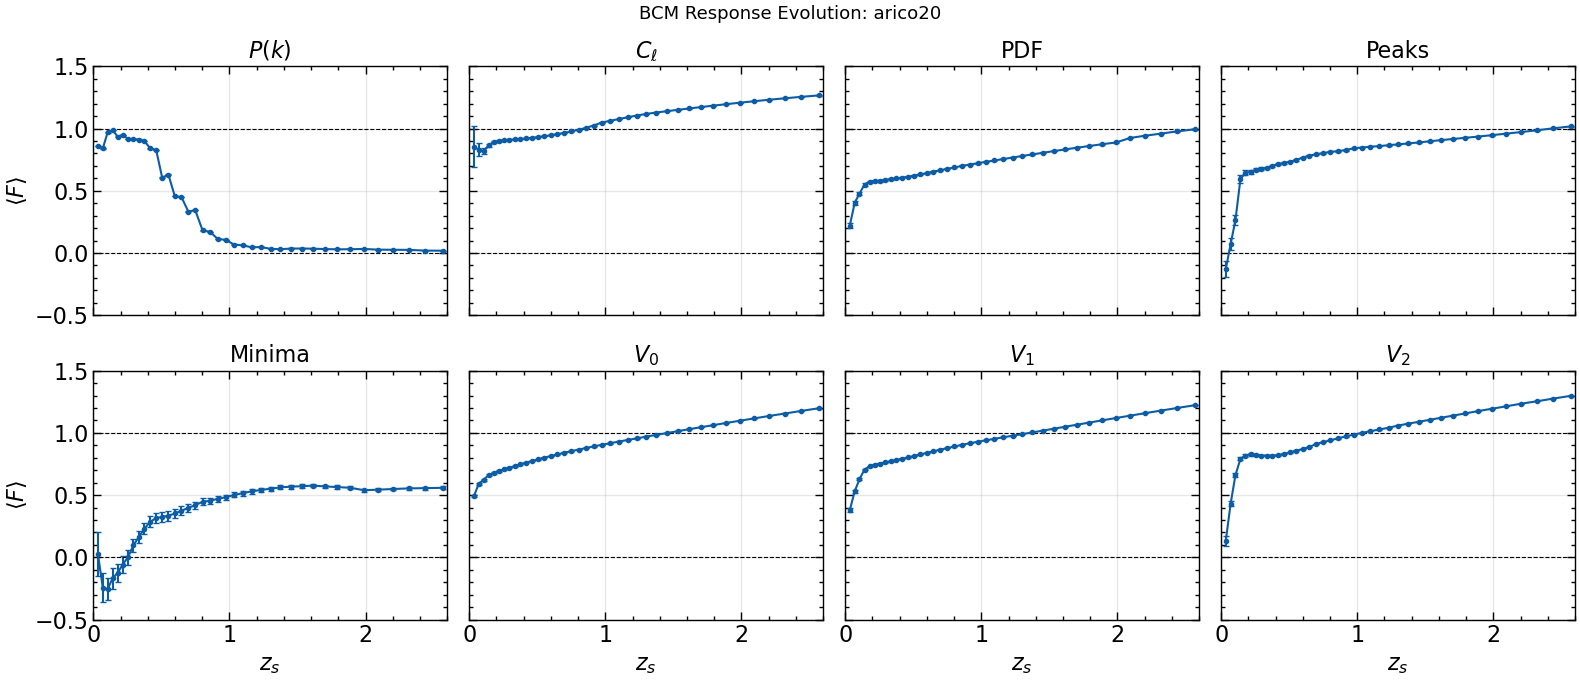

In [17]:
# Redshift evolution of <F> for each statistic
for model_name in bcm_results:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
    axes_flat = axes.flatten()
    
    for i, stat_name in enumerate(STATISTICS):
        ax = axes_flat[i]
        if stat_name in bcm_results[model_name]:
            r = bcm_results[model_name][stat_name]
            F_vs_z = r['weighted_mean_F']
            F_err_vs_z = r['weighted_mean_F_err']
            
            valid = np.isfinite(F_vs_z)
            z_arr = np.array(REDSHIFTS_ALL)
            ax.errorbar(z_arr[valid], F_vs_z[valid], yerr=F_err_vs_z[valid],
                        fmt='o-', color='C0', lw=1.5, markersize=3, capsize=2)
        
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.axhline(1, color='k', ls='--', lw=0.8)
        ax.set_ylim(-0.5, 1.5)
        ax.set_xlim(0, 2.6)
        ax.set_title(STAT_LABELS[stat_name])
        ax.grid(alpha=0.3)
        if i >= 4:
            ax.set_xlabel(r'$z_s$')
        if i % 4 == 0:
            ax.set_ylabel(r'$\langle F \rangle$')
    
    fig.suptitle(f'BCM Response Evolution: {model_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

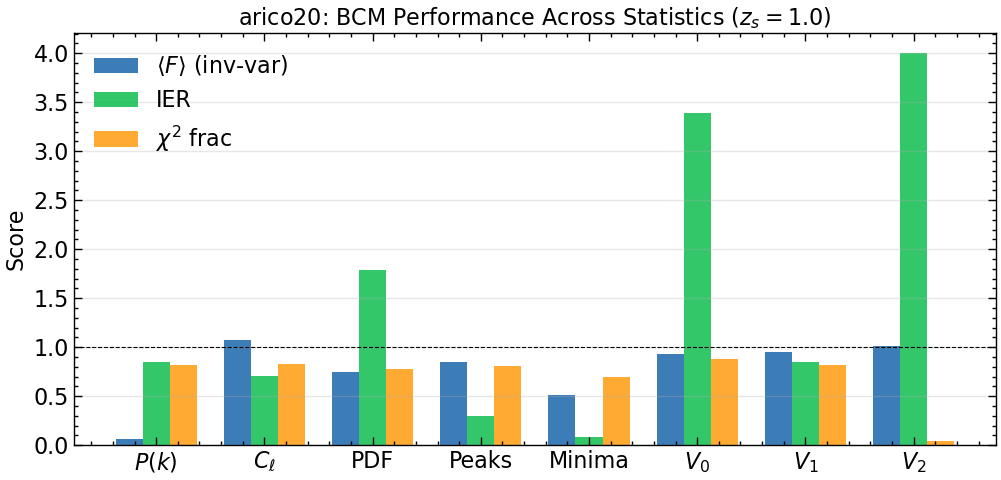

In [18]:
# Cross-statistic bar chart at z=1.0
z_idx = 23

for model_name in bcm_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    stat_names_plot = []
    F_vals = []
    F_errs = []
    ier_vals = []
    chi2_vals = []
    
    for stat_name in STATISTICS:
        if stat_name in bcm_results[model_name]:
            r = bcm_results[model_name][stat_name]
            stat_names_plot.append(STAT_LABELS[stat_name])
            F_vals.append(r['weighted_mean_F'][z_idx])
            F_errs.append(r['weighted_mean_F_err'][z_idx])
            ier_vals.append(r['integrated_scores']['IER'][z_idx])
            chi2_vals.append(r['integrated_scores']['chi2_frac'][z_idx])
    
    x = np.arange(len(stat_names_plot))
    width = 0.25
    
    ax.bar(x - width, F_vals, width, label=r'$\langle F \rangle$ (inv-var)', color='C0', alpha=0.8)
    ax.bar(x, ier_vals, width, label='IER', color='C1', alpha=0.8)
    ax.bar(x + width, chi2_vals, width, label=r'$\chi^2$ frac', color='C2', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(stat_names_plot)
    ax.axhline(0, color='k', ls='-', lw=0.5)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name}: BCM Performance Across Statistics ($z_s = 1.0$)')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [19]:
# Integrated scores comparison table at z=1.0
z_idx = 23

for model_name in bcm_results:
    print(f'\n{"=" * 85}')
    print(f'INTEGRATED SCORES: {model_name} at z_s = 1.0')
    print(f'{"=" * 85}')
    print(f'{"Statistic":<10} | {"<F> (iv)":>10} | {"IER":>10} | {"chi2_frac":>10} | {"mean_F":>10} | {"rms_F":>10}')
    print('-' * 85)
    
    for stat_name in STATISTICS:
        if stat_name in bcm_results[model_name]:
            r = bcm_results[model_name][stat_name]
            wm = r['weighted_mean_F'][z_idx]
            s = r['integrated_scores']
            ier = s['IER'][z_idx]
            chi2 = s['chi2_frac'][z_idx]
            mean_f = s['mean_F'][z_idx]
            rms_f = s['rms_F'][z_idx]
            print(f'{stat_name:<10} | {wm:>10.4f} | {ier:>10.4f} | {chi2:>10.4f} | {mean_f:>10.4f} | {rms_f:>10.4f}')


INTEGRATED SCORES: arico20 at z_s = 1.0
Statistic  |   <F> (iv) |        IER |  chi2_frac |     mean_F |      rms_F
-------------------------------------------------------------------------------------
Pk         |     0.0625 |     0.8524 |     0.8232 |     0.5462 |    38.9415
Cl         |     1.0761 |     0.7066 |     0.8272 |     1.0361 |     1.0752
pdf        |     0.7439 |     1.7863 |     0.7816 |     0.2955 |     2.0950
peaks      |     0.8541 |     0.2957 |     0.8106 |     1.0315 |     1.6148
minima     |     0.5152 |     0.0822 |     0.6981 |    -0.5001 |     3.3471
V0         |     0.9297 |     3.3863 |     0.8771 |     0.9554 |     1.0454
V1         |     0.9525 |     0.8502 |     0.8205 |     0.9845 |     1.0536
V2         |     1.0134 |     4.0027 |     0.0399 |     0.8949 |     1.6944
